# 05 — Linear Regression, Deep Dive
**Goal:** Master the model that the rest of the course keeps coming back to —
its derivation, its assumptions, its diagnostics, and the first big
generalization (regularization). Source: ISLR Ch3, Bishop Ch3, Murphy Ch7.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/learning_courses')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
np.random.seed(5)

## 1. The model

Given a feature matrix X ∈ ℝⁿˣᵈ and a target y ∈ ℝⁿ, linear regression
assumes

    y = Xβ + ε,    ε ~ N(0, σ² I)

where β ∈ ℝᵈ are the coefficients. The noise ε is assumed to be independent
of X with constant variance (homoscedastic).

Three equivalent justifications for the same estimator:

- **Least squares** — minimize ‖y − Xβ‖² (geometry: orthogonal projection).
- **MLE** under Gaussian noise — same answer, different story.
- **Best linear unbiased estimator (Gauss-Markov)** — minimum variance among
  unbiased linear estimators (under the assumptions).

## 2. The closed-form solution

Setting the gradient of the SSE to zero:

    ∇_β ‖y - Xβ‖² = -2 X⊤(y - Xβ) = 0
    X⊤X β = X⊤y
    β̂  = (X⊤X)⁻¹ X⊤ y    when X⊤X is invertible
    β̂  = X⁺ y             (pseudoinverse, always defined)

If d > n (more features than examples) or features are collinear, X⊤X is
singular and the OLS estimator does not exist. This is the setup for
regularization in notebook 08.

In [2]:
# Closed form vs sklearn vs statsmodels
np.random.seed(0)
n, d = 100, 3
X = np.random.randn(n, d)
beta = np.array([1, -2, 0.5])
y = X @ beta + 0.3 * np.random.randn(n)

X1 = np.hstack([np.ones((n, 1)), X])
beta_cf = np.linalg.inv(X1.T @ X1) @ X1.T @ y
beta_sk = LinearRegression(fit_intercept=True).fit(X, y).coef_
beta_sm = sm.OLS(y, X1).fit().params
print('closed-form :', np.round(beta_cf, 4))
print('sklearn     :', np.round(np.r_[LinearRegression().fit(X, y).intercept_, beta_sk], 4))
print('statsmodels :', np.round(beta_sm, 4))

closed-form : [-0.0546  0.9874 -2.0152  0.5124]
sklearn     : [-0.0546  0.9874 -2.0152  0.5124]
statsmodels : [-0.0546  0.9874 -2.0152  0.5124]


## 3. Geometric interpretation

The OLS solution is the **orthogonal projection of y onto the column space
of X**. The residual vector y − Xβ̂ is perpendicular to every column of X.

This picture is the one to keep in your head when you later read about:
- PCA (projection onto principal components)
- Linear regression via gradient descent (iteratively improving the
  projection)
- The hat matrix H = X(X⊤X)⁻¹X⊤ (the projection matrix itself)

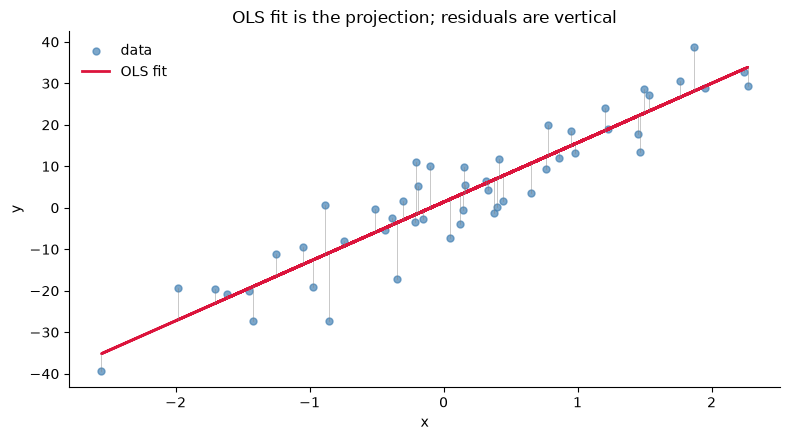

In [3]:
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=50, n_features=1, noise=8, random_state=0)
X1 = np.hstack([np.ones((len(X), 1)), X])
beta = np.linalg.lstsq(X1, y, rcond=None)[0]
y_hat = X1 @ beta

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(X, y, s=25, alpha=0.7, color='steelblue', label='data')
ax.plot(X, y_hat, color='crimson', lw=2, label='OLS fit')
for xi, yi, yhi in zip(X.ravel(), y, y_hat):
    ax.plot([xi, xi], [yi, yhi], color='gray', lw=0.5, alpha=0.6)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('OLS fit is the projection; residuals are vertical')
ax.legend(frameon=False, loc='upper left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Sampling distribution of β̂

Under the classical assumptions, β̂ is itself a random variable. Its
distribution is

    β̂ ~ N(β,  σ² (X⊤X)⁻¹)

From this we get:
- **Standard error** of β̂ⱼ :  SE(β̂ⱼ) = σ̂ √[(X⊤X)⁻¹]ⱼⱼ
- **t-statistic**            :  t = β̂ⱼ / SE(β̂ⱼ)
- **p-value**                :  2(1 - T_{n-d}(|t|))
- **Confidence interval**    :  β̂ⱼ ± t_{1-α/2, n-d} · SE(β̂ⱼ)

These are the columns of a regression summary table.

In [4]:
import pandas as pd
df = pd.read_csv('data/clean/unified_daily.csv', parse_dates=['date'])
df = df.dropna()
X = sm.add_constant(df[['spend', 'impressions', 'clicks']])
y = df['paid_conv']
fit = sm.OLS(y, X).fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:              paid_conv   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     1.724
Date:                Mon, 29 Jun 2026   Prob (F-statistic):              0.168
Time:                        17:00:10   Log-Likelihood:                -337.03
No. Observations:                  90   AIC:                             682.1
Df Residuals:                      86   BIC:                             692.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          30.7729      8.322      3.698      

## 5. The four diagnostic plots

After fitting, look at the residuals. Four patterns and what they mean.

1. **Residuals vs fitted** — should be a shapeless cloud around 0. A pattern
   means the linear model is wrong (missing a term, non-linearity).
2. **Q-Q plot** — should hug the line. Departures mean heavy tails (use
   robust regression) or skewness (transform y).
3. **Scale-location** — should be flat. A funnel shape means
   heteroscedasticity (use weighted least squares or robust SE).
4. **Residuals vs leverage** — points outside the dashed Cook's distance
   line are influential; investigate them.

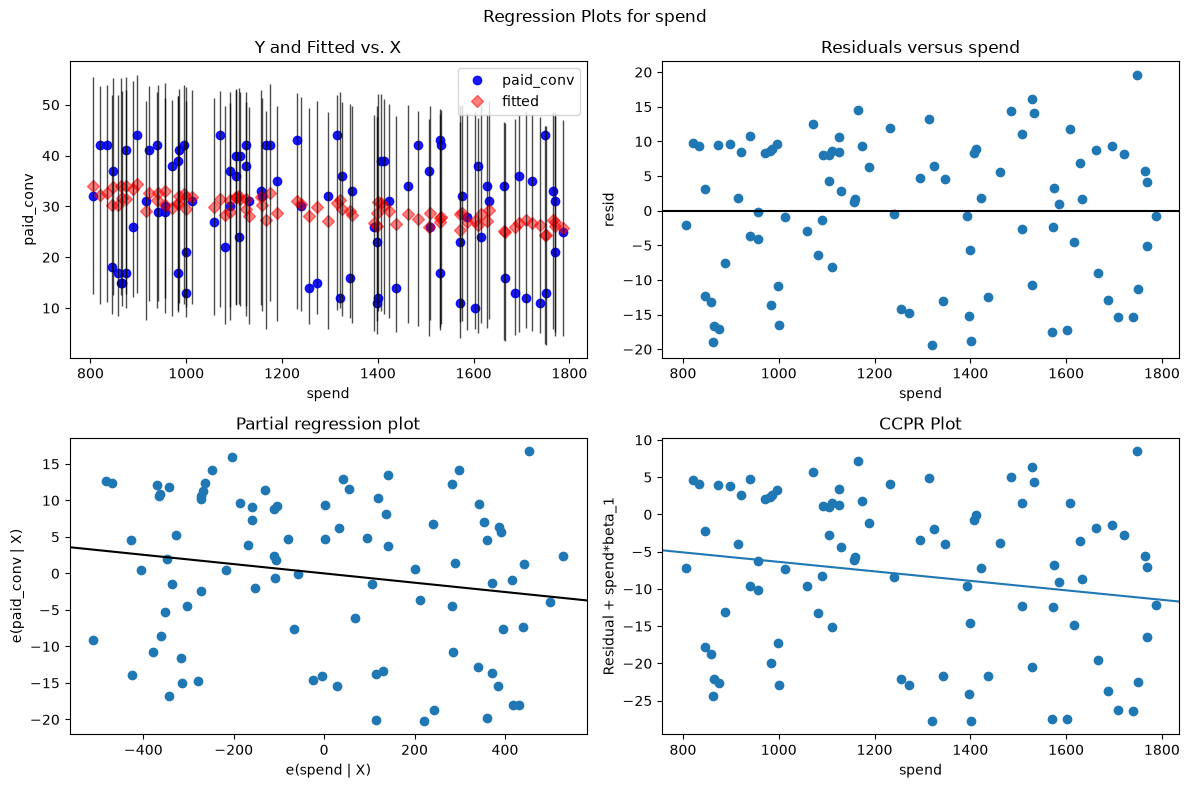

In [5]:
fig = plt.figure(figsize=(12, 8))
sm.graphics.plot_regress_exog(fit, 'spend', fig=fig)
plt.tight_layout(); plt.show()

## 6. The Gauss-Markov assumptions

OLS is BLUE (Best Linear Unbiased Estimator) **if and only if**:

1. **Linearity in parameters** — E[Y|X] = Xβ.
2. **Strict exogeneity** — E[ε | X] = 0 (no omitted variables).
3. **No perfect multicollinearity** — X has full column rank.
4. **Homoscedasticity** — Var(ε | X) = σ² I.
5. **No autocorrelation** — Cov(εᵢ, εⱼ | X) = 0 for i ≠ j.

**Violations:**
- 1 fails → add features, transform, switch to non-linear model.
- 2 fails → omitted variable bias; find the variable.
- 3 fails → drop collinear columns or use ridge/PCA.
- 4 fails → heteroscedasticity-robust SE (`HC0..HC3`) or GLS.
- 5 fails → HAC / Newey-West SE (for time series).

In [6]:
# Heteroscedasticity-robust SE
fit_hc = sm.OLS(y, X).fit(cov_type='HC3')
print('default SE vs HC3 robust SE for the spend coefficient:')
print('  default SE:', round(fit.bse['spend'], 5))
print('  HC3 SE    :', round(fit_hc.bse['spend'], 5))

default SE vs HC3 robust SE for the spend coefficient:
  default SE: 0.00377
  HC3 SE    : 0.00395


## 7. R² and adjusted R²

**R²** is the fraction of variance explained:
    R² = 1 - Σ(y - ŷ)² / Σ(y - ȳ)²

It can be made arbitrarily large by adding features. **Adjusted R²**
penalizes complexity:
    R²_adj = 1 - (1 - R²) · n/(n - d - 1)

R² is *not* a good metric for picking models — use cross-validated error.
R² is a good *summary* of a single fit.

In [7]:
n = 50
X = np.random.randn(n, 5)
y = X[:, 0] + 0.05 * np.random.randn(n)
for k in range(1, 6):
    m = LinearRegression().fit(X[:, :k], y)
    r2  = r2_score(y, m.predict(X[:, :k]))
    r2a = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    print(f'k={k}: R\u00b2 = {r2:.3f}  adj R\u00b2 = {r2a:.3f}')

k=1: R² = 0.997  adj R² = 0.997
k=2: R² = 0.997  adj R² = 0.997
k=3: R² = 0.997  adj R² = 0.997
k=4: R² = 0.997  adj R² = 0.997
k=5: R² = 0.997  adj R² = 0.997


## 8. When OLS fails — alternatives

| Problem | Remedy |
|---|---|
| Outliers in y | Huber loss, RANSAC, quantile regression |
| Outliers in X | Robust regression (RLM), LAD |
| Non-linear E[Y\|X] | Polynomial features, splines, GAM, kernel methods |
| Heteroscedastic noise | WLS, GLS, robust SE |
| Correlated errors | GLS, Newey-West HAC SE, time-series models |
| d > n | Ridge / Lasso / Elastic Net (notebook 08) |
| Heavy-tailed errors | Quantile regression, Student-t likelihood |

**A useful heuristic:** if R² < 0.5 the model is *under*-specified — the
problem is bias; add features. If R² > 0.9 on training and R² < 0.5 on test
the model is *over*-specified — the problem is variance; regularize.

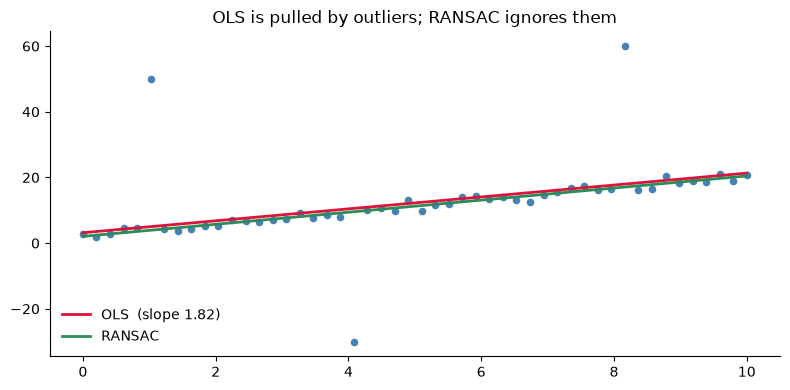

In [8]:
# Demonstration: OLS on data with outliers — RANSAC is robust
from sklearn.linear_model import RANSACRegressor
np.random.seed(0)
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 2 * X.ravel() + 1 + np.random.normal(0, 1, 50)
y[5], y[20], y[40] = 50, -30, 60  # outliers

ols  = LinearRegression().fit(X, y)
rans = RANSACRegressor(random_state=0).fit(X, y)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(X, y, s=20, color='steelblue')
xs = np.linspace(0, 10, 100).reshape(-1, 1)
ax.plot(xs, ols.predict(xs),  color='crimson',  lw=2, label=f'OLS  (slope {ols.coef_[0]:.2f})')
ax.plot(xs, rans.predict(xs), color='seagreen', lw=2, label='RANSAC')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
ax.set_title('OLS is pulled by outliers; RANSAC ignores them')
plt.tight_layout(); plt.show()

## 9. The F-test — does the model explain anything?

The omnibus F-test asks whether *all* slopes are zero:

    F = (RSS₀ - RSS) / d  ÷  RSS / (n - d - 1)

Under H₀ (all βⱼ = 0) this follows F_{d, n-d-1}. A small p-value rejects.

**Caveat:** the F-test is testing only whether the model is *better than the
intercept-only model*. It tells you nothing about whether the model is
*useful* — that is the job of out-of-sample evaluation.

In [9]:
print('F-statistic :', round(fit.fvalue, 2))
print('F p-value   :', f'{fit.f_pvalue:.2e}')

F-statistic : 1.72
F p-value   : 1.68e-01


## Summary

| Concept | Key point |
|---|---|
| Model | y = Xβ + ε, ε Gaussian |
| Solution | β̂ = (X⊤X)⁻¹ X⊤y  (or X⁺y) |
| Geometry | orthogonal projection of y onto col(X) |
| Sampling dist | β̂ ~ N(β, σ² (X⊤X)⁻¹) |
| Assumptions | Linearity, exogeneity, no collinearity, homoscedastic, uncorrelated errors |
| Diagnostics | residual plots, Q-Q, scale-location, leverage |
| F-test | omnibus — is *any* slope nonzero? |
| Failure modes | outliers, non-linearity, d > n, heteroscedasticity |

**Next:** `06_classification_theory.ipynb` — from regression to
classification.